In [2]:
#before handling outlier by any method we must discuss with out business team.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

salary = [11,40,45,68,65,68,78,90,57,74,91,92,88,68,57,48,99,101,68,77,110,140]


In [5]:
#five point summary
q1,q2,q3,q4,q5 = np.quantile(salary,[0,0.25,0.5,0.75,1])
print(q1,q2,q3,q4,q5)

11.0 59.0 71.0 90.75 140.0


In [7]:
df = pd.DataFrame(salary,columns=['Salary'])
df

,Salary
0,11
1,40
2,45
3,68
4,65
5,68
6,78
7,90
8,57
9,74


In [8]:
df.describe()

,Salary
count,22.000000
mean,74.318182
std,27.201867
min,11.000000
25%,59.000000
50%,71.000000
75%,90.750000
max,140.000000


In [ ]:
# outlier : extreame high values or extream low values
# lower_fence = q1 - IQR*1.5
# upper_fence = q3 + IQR*1.5

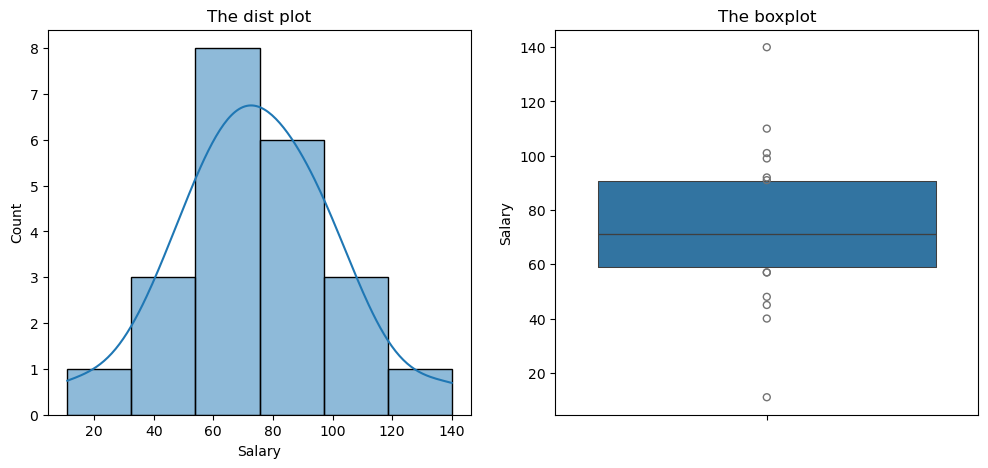

In [10]:
#detecting outlier using hisplot, boxplot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Salary'],kde=True)
plt.title("The dist plot")
plt.subplot(1,2,2)
sns.boxenplot(df['Salary'])
plt.title("The boxplot")
plt.show()

In [ ]:
'''handling outliers
1.droping the outliers
2.capping the outliers
3.replace with mean/median'''


In [13]:
#dropping the outliers
q1 = df['Salary'].quantile(0.25)
q3 = df['Salary'].quantile(0.75)
IQR = q3-q1
lower_fence = q1 - IQR*1.5
upper_fence = q3 + IQR*1.5
print(lower_fence,upper_fence)

11.375 138.375


In [24]:
#below 11.375 and above 138.375 salaries are considered as outliers
df_filtered = df[(df['Salary'] >= lower_fence) & (df['Salary']<=upper_fence)]

In [26]:
df_filtered.shape, df.shape

((20, 1), (22, 1))

<function matplotlib.pyplot.show(close=None, block=None)>

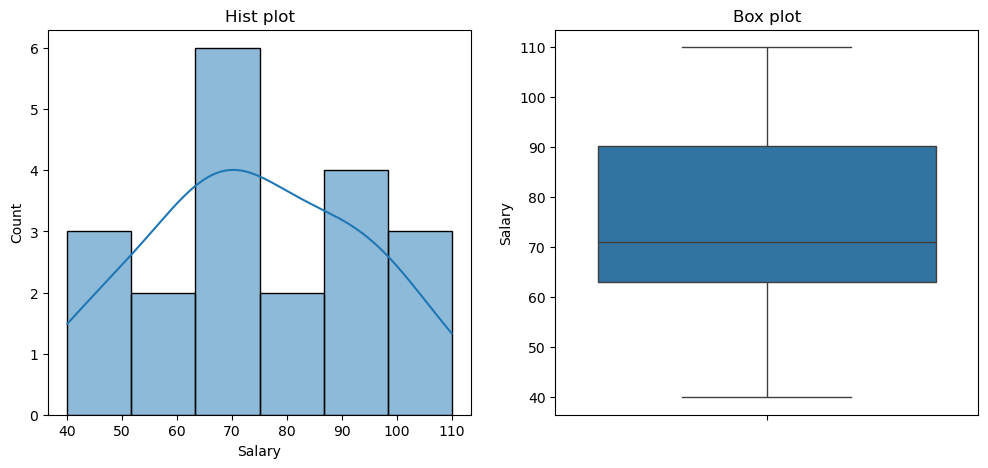

In [31]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_filtered['Salary'],kde=True)
plt.title('Hist plot')
plt.subplot(1,2,2)
sns.boxplot(df_filtered['Salary'])
plt.title("Box plot")
plt.show

In [32]:
#now no outliers are present.

In [38]:
#method 2: imputation with mean and median
df['Salary_imputed_mean'] = np.where((df['Salary'] >=upper_fence) | (df['Salary']<= lower_fence),df['Salary'].mean(),df['Salary'])
# condition : array_like, bool
# Where True, yield x, otherwise yield y.

# x, y : array_like
# Values from which to choose. x, y and condition need to be broadcastable to some shape.
df['Salary_imputed_mean'], df

(0      74.318182
 1      40.000000
 2      45.000000
 3      68.000000
 4      65.000000
 5      68.000000
 6      78.000000
 7      90.000000
 8      57.000000
 9      74.000000
 10     91.000000
 11     92.000000
 12     88.000000
 13     68.000000
 14     57.000000
 15     48.000000
 16     99.000000
 17    101.000000
 18     68.000000
 19     77.000000
 20    110.000000
 21     74.318182
 Name: Salary_imputed_mean, dtype: float64,
     Salary  Salary_imputed_mean
 0       11            74.318182
 1       40            40.000000
 2       45            45.000000
 3       68            68.000000
 4       65            65.000000
 5       68            68.000000
 6       78            78.000000
 7       90            90.000000
 8       57            57.000000
 9       74            74.000000
 10      91            91.000000
 11      92            92.000000
 12      88            88.000000
 13      68            68.000000
 14      57            57.000000
 15      48            48.000000

<Axes: ylabel='Salary_imputed_mean'>

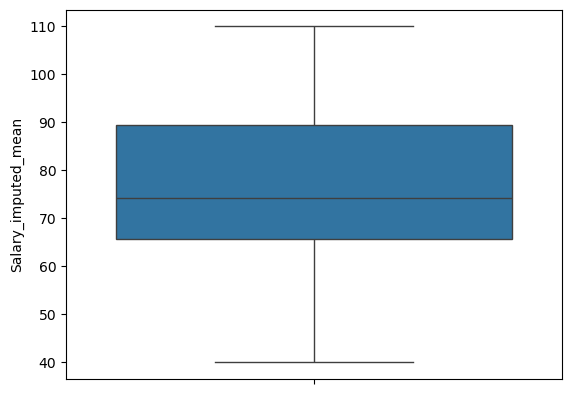

In [39]:
sns.boxplot(df['Salary_imputed_mean'])

In [40]:
#method 3: capping. (replacing with the nearest value which not outlier)
lower_cap =df['Salary'].quantile(0.05) #lower cap as 5th percentile
upper_cap = df['Salary'].quantile(0.95) #uppercap as 95th percentile
lower_cap,upper_cap

(40.25, 109.55)

In [47]:
#replace outliers with the caps
df_capped = np.where(df['Salary']<=lower_fence, lower_cap,
         np.where(df['Salary']>=upper_fence, upper_cap,df['Salary']))

<Axes: >

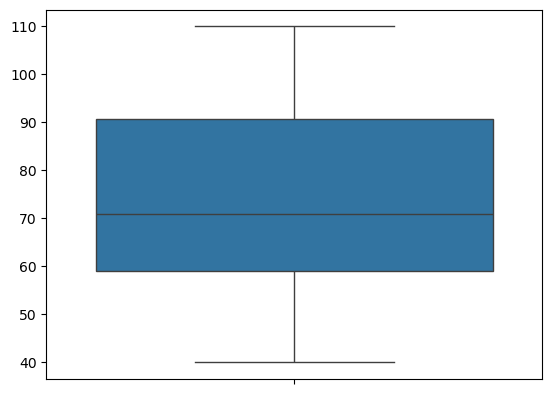

In [48]:
sns.boxplot(df_capped)